Some current map products available online: 
* https://www.h1bwagemap.com, 
* https://cis.org/Full-Screen-Map-H-1B-Dependent-Employers, 
* https://github.com/yoncheong/Visualization_Project_H1B, 
* https://www.kaggle.com/code/jmpark746/exploratory-data-analysis-of-h-1b-visas, 
* https://conormclaughlin.net/2019/04/h1-b-visa-analysis/
* https://cis.org/H1B-Employer-Maps-Dependent-Willful-Violator-and-Debarred

# Setup

In [ ]:
import pandas
import pandas as pd
import os
import geopandas
import geopandas as gpd

In [ ]:
dataPath = r'C:\Users\eagle\Downloads\LCA_Disclosure_Data_FY2025_Q1.csv' # data source: https://www.dol.gov/agencies/eta/foreign-labor/performance
popDataPath = r"C:\Users\eagle\OneDrive\Documents\Data\NST-EST2025-ALLDATA.csv"
pathFortune1000 = r"C:\Users\eagle\OneDrive\Documents\Data\archive\fortune1000_2024.csv"
pathFortune500 = r'C:\Users\eagle\OneDrive\Documents\Data\archive\fortune500_2025_from50pros.csv'
americanStatesPath = r"C:\Users\eagle\OneDrive\Documents\Data\cb_2018_us_state_500k\cb_2018_us_state_500k.shp"
citiesShapefilePath = r'C:\Users\eagle\OneDrive\Documents\Data\ne_110m_populated_places'
americanCitiesPath = r'C:\Users\eagle\OneDrive\Documents\Data\tl_2025_01_place\tl_2025_01_place.shp' # more granular
anotherAmericanCitiesPath = r'C:\Users\eagle\OneDrive\Documents\Data\cb_2024_us_place_500k\cb_2024_us_place_500k.shp' # more general


In [ ]:
data = pandas.read_csv(dataPath)

C:\Users\eagle\AppData\Local\Temp\ipykernel_17792\229269823.py:1: DtypeWarning: Columns (90) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pandas.read_csv(dataPath)


In [ ]:
data.shape

(107414, 97)

In [7]:
os.path.getsize(dataPath)/1024

85974.3056640625

If we consider using databases that are not files, we could consider to try shiny or streamlit. Could also consider https://git-lfs.com

# These files are very large, so we want to figure out a way to shrink them down to salient features before aggregating them and sharing them online.

#### How many columns are there and what would we need?

In [8]:
data.columns

Index(['CASE_NUMBER', 'CASE_STATUS', 'RECEIVED_DATE', 'DECISION_DATE',
       'ORIGINAL_CERT_DATE', 'VISA_CLASS', 'JOB_TITLE', 'SOC_CODE',
       'SOC_TITLE', 'FULL_TIME_POSITION', 'BEGIN_DATE', 'END_DATE',
       'TOTAL_WORKER_POSITIONS', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
       'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
       'CHANGE_EMPLOYER', 'AMENDED_PETITION', 'EMPLOYER_NAME',
       'TRADE_NAME_DBA', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2',
       'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_POSTAL_CODE',
       'EMPLOYER_COUNTRY', 'EMPLOYER_PROVINCE', 'EMPLOYER_PHONE',
       'EMPLOYER_PHONE_EXT', 'EMPLOYER_FEIN', 'NAICS_CODE',
       'EMPLOYER_POC_LAST_NAME', 'EMPLOYER_POC_FIRST_NAME',
       'EMPLOYER_POC_MIDDLE_NAME', 'EMPLOYER_POC_JOB_TITLE',
       'EMPLOYER_POC_ADDRESS1', 'EMPLOYER_POC_ADDRESS2', 'EMPLOYER_POC_CITY',
       'EMPLOYER_POC_STATE', 'EMPLOYER_POC_POSTAL_CODE',
       'EMPLOYER_POC_COUNTRY', 'EMPLOYER_POC_PROVINCE', 'EMPLOYER_POC_PHON

Its curious why some columns are there when we assume it will always have a similar data point. Let's see if that's the case.

#### Aren't there some obvious attributes here that don't need to be in the table?

In [9]:
with pandas.option_context('display.max_rows', None, 'display.max_columns', None):
    print(data[['VISA_CLASS', 'FULL_TIME_POSITION', 'TOTAL_WORKER_POSITIONS']].value_counts())

VISA_CLASS       FULL_TIME_POSITION  TOTAL_WORKER_POSITIONS
H-1B             Y                   1                         97655
                                     10                         2410
E-3 Australian   Y                   1                          2260
H-1B             N                   1                          1749
H-1B1 Chile      Y                   1                           483
H-1B1 Singapore  Y                   1                           387
H-1B             Y                   3                           362
                                     5                           356
                                     20                          268
                                     25                          249
                                     50                          219
                                     2                           201
                                     6                           154
                                     40    

Looks like Chileans, Singaporeans, and Australians have a unique version for the skill based non-immigrant/dual-intent visa. It's also surprising that an application has worker positions column suggesting that it may either be a count of the workers in the organizations or number of applicants falling within the application? Its not clear why there would be non-unitary values there. But, as expected the majority of the data falls into full time positions for a single unit of worker.

#### What else is there besides Certified, Withdraw, and Denied in `CASE_STATUS`?

In [10]:
data['CASE_STATUS'].unique()

array(['Withdrawn', 'Denied', 'Certified', 'Certified - Withdrawn'],
      dtype=object)

#### Let's check out how this truncated dataset looks like

In [11]:
data.head()[['CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 
             'BEGIN_DATE', 'END_DATE', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
             'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
             'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
             'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE',
             'WORKSITE_WORKERS', 'WORKSITE_CITY', 'WORKSITE_COUNTY',
       'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE']]

,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,CHANGE_PREVIOUS_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,0,...,0,"FIRST TEK, INC.",II,"Piscataway,",NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,0,...,0,CYBAGE SOFTWARE INC,II,PRINCETON JUNCTION,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,BEDMINSTER,NJ,1,IRVING,DALLAS,TX,75039


Convert wage data to all hourly or yearly?

#### What are the unique job title classes?

In [12]:
jobTitles = data['SOC_TITLE'].unique().tolist()

In [13]:
for job in jobTitles:
    print(job)

Database Administrators
Radiologists
Information Technology Project Managers
Computer Systems Analysts
Physicians, All Other
General and Operations Managers
Software Developers
Mechanical Engineers
Biological Technicians
Family Medicine Physicians
Procurement Clerks
Data Scientists
Marketing Managers
Market Research Analysts and Marketing Specialists
Commercial and Industrial Designers
Special Effects Artists and Animators
Dentists, General
Software Quality Assurance Analysts and Testers
Parts Salespersons
Chief Executives
Computer and Information Systems Managers
Validation Engineers
Architects, Except Landscape and Naval
Mental Health Counselors
Business Intelligence Analysts
Construction Managers
Statisticians
Transportation, Storage, and Distribution Managers
Network and Computer Systems Administrators
Educational, Guidance, and Career Counselors and Advisors
Materials Engineers
Industrial Engineers
Home Health Aides
Web and Digital Interface Designers
Electrical Engineers
Operatio

#### What is the frequency of job titles?

In [14]:
jobTitlesCount = data['SOC_TITLE'].value_counts()

In [15]:
jobTitlesCount

SOC_TITLE
Software Developers                                              37240
Computer Systems Engineers/Architects                             5078
Information Technology Project Managers                           4154
Software Quality Assurance Analysts and Testers                   3691
Computer and Information Systems Managers                         3235
                                                                 ...  
Advanced Practice Psychiatric Nurses                                 1
VETERINARIANS                                                        1
Robotics Engineer                                                    1
Computer Science Teachers                                            1
First-Line Supervisors of Housekeeping and Janitorial Workers        1
Name: count, Length: 600, dtype: int64

This one is kind of obvious.

In [16]:
spatialDistribution = data['WORKSITE_STATE'].value_counts()

# Let's try to make a map of states with major technology companies within them ranked

In [17]:
americanStates = geopandas.read_file(americanStatesPath)

<Axes: >

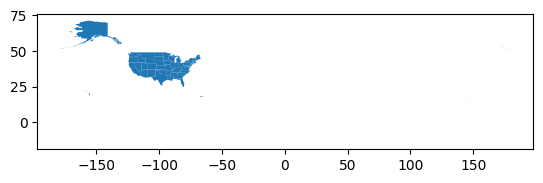

In [18]:
americanStates.plot()

In [19]:
americanStates.head()

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."


#### Let's first look at the fortune 500 companies

In [20]:
fortune500 = pandas.read_csv(pathFortune500)

In [21]:
fortune500.head()

,Rank,Company,Industry,City,State,Zip Code,Website,Employees,Revenue (rounded),CEO
0,1,Walmart,General Merchandisers,Bentonville,Arkansas,72716,walmart.com,"2,100,000","$681,000,000,000",Douglas McMillon
1,2,Amazon,Internet Services and Retailing,Seattle,Washington,98109,amazon.com,"1,556,000","$638,000,000,000",Andrew Jassy
2,3,UnitedHealth,Health Care: Insurance and Managed Care,Eden Prairie,Minnesota,55344,unitedhealthgroup.com,"400,000","$400,300,000,000",Stephen Hemsley
3,4,Apple,"Computers, Office Equipment",Cupertino,California,95014,apple.com,"164,000","$391,000,000,000",Timothy Cook
4,5,CVS Health,Health Care: Pharmacy and Other Services,Woonsocket,Rhode Island,2895,cvshealth.com,"259,500","$372,800,000,000",David Joyner


In [22]:
fortune500['State'].value_counts()

State
California              58
Texas                   54
New York                53
Illinois                32
Ohio                    28
Virginia                25
Florida                 22
Pennsylvania            19
Minnesota               17
Georgia                 17
Massachusetts           16
Connecticut             15
New Jersey              15
Michigan                15
North Carolina          11
Washington              11
Tennessee               11
Arizona                  9
Wisconsin                8
Colorado                 8
Indiana                  8
Missouri                 8
Rhode Island             5
Arkansas                 4
Nebraska                 4
Kentucky                 3
District Of Columbia     3
Oklahoma                 3
Maryland                 3
Nevada                   3
Idaho                    2
Oregon                   2
Iowa                     2
Louisiana                2
Alabama                  2
Delaware                 1
Kansas                

In [23]:
fortune500Geom = fortune500.merge(
    americanStates[['NAME', 'geometry']],
    left_on=['State'],
    right_on=['NAME'],
    how='left'
)

In [24]:
americanStates[americanStates['NAME'].isin(set(americanStates['NAME']) - set(fortune1000Freq.keys()))].plot()

NameError: name 'fortune1000Freq' is not defined

<Axes: >

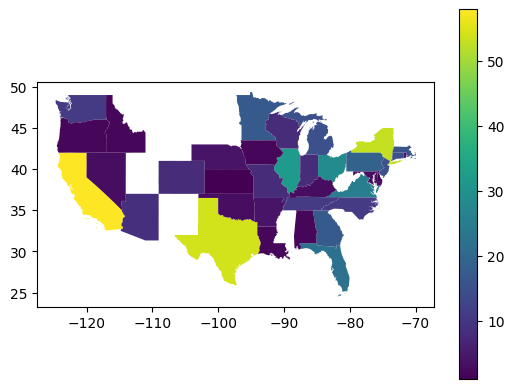

In [ ]:
fortune500FreqGeom.plot(column = "count", legend = "true", missing_kwds={'color': 'red', 'aspect': 'equal'})

In [26]:
fortune500Freq = fortune500['State'].value_counts()

In [27]:
fortune500FreqGeom = fortune500Freq.to_frame().merge(
    americanStates[['NAME', 'geometry']],
    left_on=['State'],
    right_on=['NAME'],
    how='left'
)

In [28]:
fortune500FreqGeom = geopandas.GeoDataFrame(fortune500FreqGeom)

<Axes: >

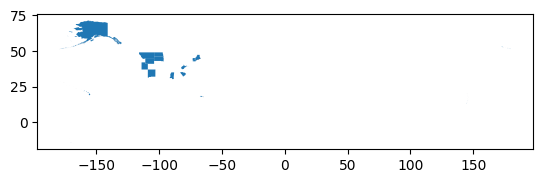

In [75]:
americanStates[americanStates['NAME'].isin(set(americanStates['NAME']) - set(fortune500Geom['State']))].plot()

In [76]:
popData = pandas.read_csv(popDataPath)

In [77]:
popData[
    popData['NAME'].isin(
            set(americanStates['NAME']) - set(fortune500Geom['State'])
        )
    ][['NAME', 'POPESTIMATE2020']].sort_values(by="POPESTIMATE2020", ascending = False)

,NAME,POPESTIMATE2020
54,South Carolina,5131992
58,Utah,3283970
65,Puerto Rico,3281591
38,Mississippi,2958385
45,New Mexico,2118446
62,West Virginia,1791670
25,Hawaii,1451130
43,New Hampshire,1378752
33,Maine,1364546
40,Montana,1087156


Lots of states don't have fortune 500 companies.

#### Let's look at the fortune 1000 companies

In [78]:
fortune1000 = pandas.read_csv(pathFortune1000)

In [79]:
fortune1000.head()

,Rank,Company,Ticker,Sector,Industry,Profitable,Founder_is_CEO,FemaleCEO,Growth_in_Jobs,Change_in_Rank,...,Assets_M,CEO,Country,HeadquartersCity,HeadquartersState,Website,CompanyType,Footnote,MarketCap_Updated_M,Updated
0,1,Walmart,WMT,Retailing,General Merchandisers,yes,no,no,no,0.0,...,252399.0,C. Douglas McMillon,U.S.,Bentonville,Arkansas,https://www.stock.walmart.com,Public,"Figures are for fiscal year ended Jan. 31, 202...",559911.0,2024-08-05
1,2,Amazon,AMZN,Retailing,Internet Services and Retailing,yes,no,no,no,0.0,...,527854.0,Andrew R. Jassy,U.S.,Seattle,Washington,https://www.amazon.com,Public,"Market value as of July 15, 2024.",2005565.0,2024-08-05
2,3,Apple,AAPL,Technology,"Computers, Office Equipment",yes,no,no,no,1.0,...,352583.0,Timothy D. Cook,U.S.,Cupertino,California,https://www.apple.com,Public,"Figures are for fiscal year ended Sept. 30, 20...",3594309.0,2024-08-05
3,4,UnitedHealth Group,UNH,Health Care,Health Care: Insurance and Managed Care,yes,no,no,yes,1.0,...,273720.0,Andrew P. Witty,U.S.,Minnetonka,Minnesota,https://www.unitedhealthgroup.com,Public,"Market value as of July 15, 2024.",474339.0,2024-08-05
4,5,Berkshire Hathaway,BRKA,Financials,Insurance: Property and Casualty (Stock),yes,no,no,yes,2.0,...,1069978.0,Warren E. Buffett,U.S.,Omaha,Nebraska,https://www.berkshirehathaway.com,Public,"Market value as of July 15, 2024.",937028.0,2024-08-05


In [80]:
fortune1000['HeadquartersState'].value_counts()

HeadquartersState
California              124
Texas                   107
New York                 78
Illinois                 58
Ohio                     51
Pennsylvania             45
Virginia                 39
Florida                  39
Georgia                  37
Massachusetts            32
Michigan                 28
North Carolina           28
Minnesota                25
Connecticut              25
Arizona                  23
Colorado                 23
New Jersey               23
Wisconsin                22
Tennessee                20
Missouri                 20
Indiana                  20
Washington               17
Maryland                 11
Nevada                   11
Oklahoma                 10
Nebraska                  8
Rhode Island              7
Kentucky                  7
Arkansas                  6
Delaware                  6
Oregon                    6
District Of Columbia      5
Idaho                     4
South Carolina            4
Kansas                    4
Ut

In [81]:
fortune1000Geom = fortune1000.merge(
    americanStates[['NAME', 'geometry']],
    left_on=['HeadquartersState'],
    right_on=['NAME'],
    how='left'
)

In [82]:
fortune1000Freq = fortune1000['HeadquartersState'].value_counts()

In [83]:
fortune1000FreqGeom = fortune1000Freq.to_frame().merge(
    americanStates[['NAME', 'geometry']],
    left_on=['HeadquartersState'],
    right_on=['NAME'],
    how='left'
)

In [84]:
fortune1000FreqGeom = geopandas.GeoDataFrame(fortune1000FreqGeom)

<Axes: >

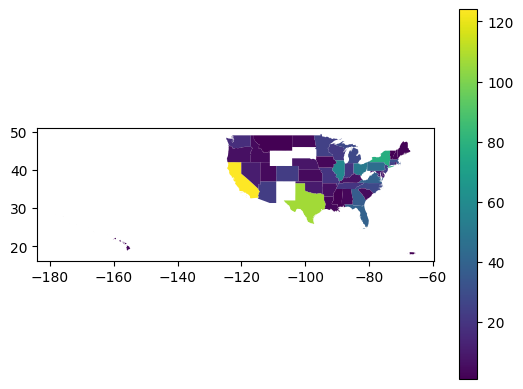

In [85]:
fortune1000FreqGeom.plot(column = "count", legend = "true", missing_kwds={'color': 'red', 'aspect': 'equal'})

In [86]:
fortune1000Freq.head()

HeadquartersState
California    124
Texas         107
New York       78
Illinois       58
Ohio           51
Name: count, dtype: int64

In [87]:
popData[popData['NAME'].isin(set(americanStates['NAME']) - set(fortune1000Freq.keys()))][['NAME', 'POPESTIMATE2020']].sort_values(by="POPESTIMATE2020", ascending = False)

,NAME,POPESTIMATE2020
45,New Mexico,2118446
62,West Virginia,1791670
55,South Dakota,887808
15,Alaska,732906
22,District of Columbia,670958
64,Wyoming,577669


I guess let's try Alaska, Wyoming, South Dakota, West Virginia and New Mexico...

# Where do skilled immigrant applicants in 2025Q1 end up getting labor applications from?

In [43]:
spatialDistribution

WORKSITE_STATE
CA    20564
TX    16772
NY     8135
WA     7346
NJ     5187
IL     4258
NC     4250
GA     4206
MA     3798
FL     3319
VA     2942
PA     2888
MI     2693
OH     2149
AZ     1977
MD     1283
TN     1281
MN     1223
CO     1131
CT     1124
MO     1047
IN     1010
AR      848
WI      779
OR      756
UT      508
DE      494
SC      479
DC      471
KY      434
IA      415
KS      353
NE      339
NV      316
AL      291
OK      274
NH      253
RI      244
LA      228
GU      192
NM      184
ID      165
MS      143
WV      111
SD       91
ME       85
ND       73
VT       66
AK       65
HI       60
MT       32
WY       32
MP       20
PR       18
VI       12
Name: count, dtype: int64

# Truncation

We choose the columns below for our data and see if it reflects a more condensed dataset.

In [44]:
dataOutPath = r'C:\Users\eagle\Downloads\unit-3\TestData'

data[['CASE_STATUS', 'JOB_TITLE', 'SOC_TITLE', 'PREVAILING_WAGE', 'PW_UNIT_OF_PAY', 
             'BEGIN_DATE', 'END_DATE', 'NEW_EMPLOYMENT', 'CONTINUED_EMPLOYMENT',
             'CHANGE_PREVIOUS_EMPLOYMENT', 'NEW_CONCURRENT_EMPLOYMENT',
             'CHANGE_EMPLOYER', 'EMPLOYER_NAME',
             'PW_WAGE_LEVEL', 'EMPLOYER_CITY', 'EMPLOYER_STATE',
             'WORKSITE_WORKERS', 'WORKSITE_CITY', 'WORKSITE_COUNTY',
       'WORKSITE_STATE', 'WORKSITE_POSTAL_CODE']].to_csv(os.path.join(dataOutPath, 'testDataSize.csv'))

In [45]:
os.path.getsize(os.path.join(dataOutPath, 'testDataSize.csv'))/1024

20058.767578125

In [46]:
truncatedDataPath = os.path.join(dataOutPath, 'testDataSize.csv')

# What are the job code frequencies?

https://www.bls.gov/oes/2023/may/oes_stru.htm is a useful page to aggregate the SOC codes for the purposes of the assignment. Interesting questions can come out of the non-information technology positions outside of the major states where it is at.

In [47]:
industries = data[['SOC_CODE', 'SOC_TITLE']]

In [48]:
industries.groupby(industries['SOC_CODE'].str[:2])['SOC_CODE'].count()

SOC_CODE
11     6867
12        2
13     6798
15    70246
17     9344
19     5180
21      532
23      472
25     2973
27      949
29     3241
31       20
33        1
35       34
37        2
39       10
41      576
43       38
45       31
47        2
49       26
51        5
53       64
54        1
Name: SOC_CODE, dtype: int64

What wage level are the medical staff?

# Can we try to join a cities shapefile to the cities identified in our skilled immigration 2025Q1 database?

In [49]:
os.listdir(citiesShapefilePath)

['ne_110m_populated_places.cpg',
 'ne_110m_populated_places.dbf',
 'ne_110m_populated_places.prj',
 'ne_110m_populated_places.README.html',
 'ne_110m_populated_places.shp',
 'ne_110m_populated_places.shx',
 'ne_110m_populated_places.VERSION.txt']

In [50]:
citiesShapefileName = 'ne_110m_populated_places.shp'

In [51]:
cities = gpd.read_file(os.path.join(citiesShapefilePath, citiesShapefileName))

<Axes: >

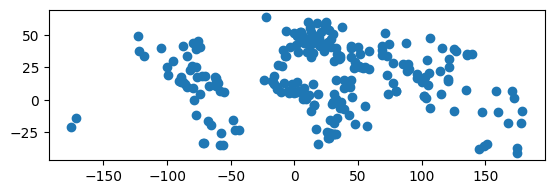

In [52]:
cities.plot()

In [53]:
americanCities = gpd.read_file(americanCitiesPath)

<Axes: >

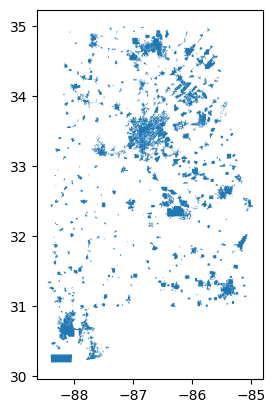

In [54]:
americanCities.plot()

In [55]:
americanCities

,STATEFP,PLACEFP,PLACENS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,PCICBSA,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,01,64152,02407196,0164152,1600000US0164152,Rehobeth,Rehobeth town,43,C1,N,G4110,A,20706750,104646,+31.1225476,-085.4396483,"MULTIPOLYGON (((-85.41906 31.16199, -85.41884 ..."
1,01,17176,02406310,0117176,1600000US0117176,Coosada,Coosada town,43,C1,N,G4110,A,17855615,620670,+32.4953941,-086.3265431,"POLYGON ((-86.35632 32.4964, -86.35502 32.4964..."
2,01,23656,02406444,0123656,1600000US0123656,Elmore,Elmore town,43,C1,N,G4110,A,16250483,362263,+32.5566058,-086.3410246,"MULTIPOLYGON (((-86.32853 32.56198, -86.32746 ..."
3,01,81720,02405723,0181720,1600000US0181720,Wetumpka,Wetumpka city,25,C1,N,G4110,A,29802978,1136032,+32.5420184,-086.2053074,"MULTIPOLYGON (((-86.2444 32.58002, -86.24428 3..."
4,01,00460,02403063,0100460,1600000US0100460,Adamsville,Adamsville city,25,C1,N,G4110,A,67897213,540470,+33.6023153,-086.9715269,"MULTIPOLYGON (((-86.91236 33.57605, -86.91211 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,01,69180,02402837,0169180,1600000US0169180,Selmont-West Selmont,Selmont-West Selmont CDP,57,U2,N,G4210,S,8491008,100742,+32.3782527,-087.0068876,"POLYGON ((-87.02226 32.38182, -87.02188 32.382..."
590,01,71201,02402861,0171201,1600000US0171201,Smoke Rise,Smoke Rise CDP,57,U1,N,G4210,S,14827454,32672,+33.8799418,-086.8246833,"POLYGON ((-86.84889 33.88657, -86.84882 33.886..."
591,01,72672,02628604,0172672,1600000US0172672,Spruce Pine,Spruce Pine CDP,57,U1,N,G4210,S,2403083,2825,+34.3928704,-087.7295968,"POLYGON ((-87.74194 34.397, -87.74092 34.39696..."
592,01,73272,02633318,0173272,1600000US0173272,Stockton,Stockton CDP,57,U1,N,G4210,S,24197952,743568,+31.0012455,-087.8739291,"POLYGON ((-87.89301 31.00656, -87.89296 31.006..."


<Axes: >

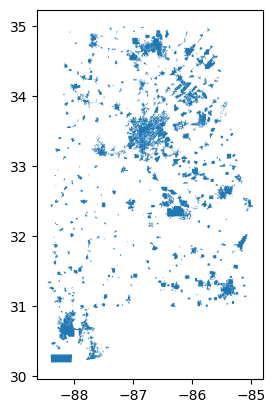

In [56]:
americanCities.plot()

In [57]:
anotherAmericanCities = gpd.read_file(anotherAmericanCitiesPath)

Source for good data on cities coordinates: https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_place_500k.zip

<Axes: >

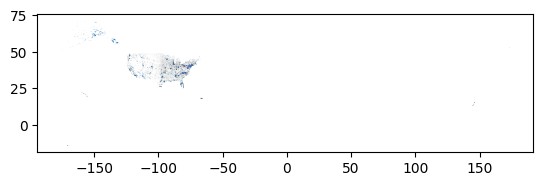

In [58]:
anotherAmericanCities.plot()

In [59]:
anotherAmericanCities.length

C:\Users\eagle\AppData\Local\Temp\ipykernel_17792\3405353109.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  anotherAmericanCities.length


0        1.237359
1        0.129710
2        1.196638
3        0.159147
4        0.059843
           ...   
32607    0.174668
32608    0.148310
32609    0.120391
32610    0.086702
32611    0.088415
Length: 32612, dtype: float64

In [60]:
anotherAmericanCities.head()

,STATEFP,PLACEFP,PLACENS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,12,53150,02404445,1600000US1253150,1253150,Ormond Beach,Ormond Beach city,FL,Florida,25,90951810,10688642,"MULTIPOLYGON (((-81.13629 29.35995, -81.13167 ..."
1,17,55899,02399571,1600000US1755899,1755899,Olmsted,Olmsted village,IL,Illinois,47,8714516,338372,"POLYGON ((-89.10348 37.16677, -89.10003 37.171..."
2,06,02000,02409704,1600000US0602000,0602000,Anaheim,Anaheim city,CA,California,25,130232149,1567025,"POLYGON ((-118.01742 33.82446, -118.01644 33.8..."
3,17,47774,02399280,1600000US1747774,1747774,Maywood,Maywood village,IL,Illinois,47,7038039,0,"POLYGON ((-87.86316 41.87118, -87.85902 41.871..."
4,19,76665,02396013,1600000US1976665,1976665,Swan,Swan city,IA,Iowa,25,1597912,0,"POLYGON ((-93.32005 41.47225, -93.30106 41.472..."


In [61]:
amerCitiesGeom = anotherAmericanCities[['NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'geometry']]

In [62]:
truncH1BData = pandas.read_csv(truncatedDataPath)

In [63]:
truncH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,"Piscataway,",NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,PRINCETON JUNCTION,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,BEDMINSTER,NJ,1,IRVING,DALLAS,TX,75039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107409,107409,Certified - Withdrawn,SENIOR SALESFORCE DEVELOPER,Computer Systems Analysts,"$146,682.00",Year,9/29/2021,9/28/2024,0,0,...,1,Snowflake Inc.,IV,San Mateo,CA,1,DUBLIN,ALAMEDA,CA,94568
107410,107410,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$35,942.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,NEWARK,DE,1,Newark,NEW CASTLE,DE,19711
107411,107411,Certified - Withdrawn,Postdoctoral Research Associate,Biochemists and Biophysicists,"$40,768.00",Year,10/2/2021,10/1/2024,0,1,...,0,Georgia State University,I,Atlanta,GA,1,Atlanta,FULTON,GA,30303
107412,107412,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$38,979.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,NEWARK,DE,1,Newark,NEW CASTLE,DE,19711


In [64]:
truncH1BData['EMPLOYER_CITY'] = truncH1BData['EMPLOYER_CITY'].str.split(',').str[0]
truncH1BData['EMPLOYER_CITY'] = truncH1BData['EMPLOYER_CITY'].str.lower().str.title()

In [65]:
truncH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107409,107409,Certified - Withdrawn,SENIOR SALESFORCE DEVELOPER,Computer Systems Analysts,"$146,682.00",Year,9/29/2021,9/28/2024,0,0,...,1,Snowflake Inc.,IV,San Mateo,CA,1,DUBLIN,ALAMEDA,CA,94568
107410,107410,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$35,942.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,Newark,DE,1,Newark,NEW CASTLE,DE,19711
107411,107411,Certified - Withdrawn,Postdoctoral Research Associate,Biochemists and Biophysicists,"$40,768.00",Year,10/2/2021,10/1/2024,0,1,...,0,Georgia State University,I,Atlanta,GA,1,Atlanta,FULTON,GA,30303
107412,107412,Certified - Withdrawn,Post Doctoral Researcher (Behavioral Health & ...,Food Scientists and Technologists,"$38,979.00",Year,10/1/2021,9/30/2024,1,0,...,0,UNIVERSITY OF DELAWARE,I,Newark,DE,1,Newark,NEW CASTLE,DE,19711


In [66]:
testH1BData = truncH1BData.head(20)

In [67]:
testH1BData

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039
5,5,Withdrawn,Assistant Professor,"Physicians, All Other","$65,936.00",Year,7/1/2025,6/30/2028,0,1,...,0,Board of Regents of the University of Nebraska,I,Omaha,NE,1,Omaha,SARPY,NE,68123
6,6,Denied,GENERAL MANAGER,General and Operations Managers,$27.36,Hour,1/31/2025,1/30/2027,1,1,...,0,H & S RESTAURANTS INC,I,Suffolk,VA,1,SUFFOLK,SUFFOLK CITY,VA,23435
7,7,Withdrawn,Oracle EBS Consultant,Software Developers,"$155,605.00",Year,4/2/2025,4/1/2026,0,1,...,0,"Intelecox, Inc.",II,San Diego,CA,1,Fremont,ALAMEDA,CA,94538
8,8,Denied,Project Engineer,Mechanical Engineers,"$73,500.00",Year,1/9/2025,1/9/2028,0,1,...,0,ECOTRON CORPORATION,NaN,Torrance,CA,1,Torrance,LOS ANGELES,CA,90503
9,9,Denied,Developer,Software Developers,"$96,555.00",Year,4/25/2025,4/24/2028,0,1,...,0,Barclays Services Corp.,NaN,New York,NY,1,Whippany,MORRIS,NJ,07981


In [68]:
testH1BDataGeom = testH1BData.merge(
    amerCitiesGeom[['NAME', 'STUSPS', 'geometry']],
    left_on=['EMPLOYER_CITY', 'EMPLOYER_STATE'],
    right_on=['NAME', 'STUSPS'],
    how='left'
)

In [69]:
testH1BDataGeom

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE,NAME,STUSPS,geometry
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391,NaN,NaN,None
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132,Salt Lake City,UT,"POLYGON ((-112.10135 40.82714, -112.07278 40.8..."
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820,Princeton Junction,NJ,"POLYGON ((-74.62923 40.33869, -74.62788 40.337..."
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359,NaN,NaN,None
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,Bedminster,NJ,1,IRVING,DALLAS,TX,75039,Bedminster,NJ,"POLYGON ((-74.68078 40.67414, -74.67787 40.675..."
5,5,Withdrawn,Assistant Professor,"Physicians, All Other","$65,936.00",Year,7/1/2025,6/30/2028,0,1,...,Omaha,NE,1,Omaha,SARPY,NE,68123,Omaha,NE,"POLYGON ((-96.26804 41.2947, -96.26803 41.2950..."
6,6,Denied,GENERAL MANAGER,General and Operations Managers,$27.36,Hour,1/31/2025,1/30/2027,1,1,...,Suffolk,VA,1,SUFFOLK,SUFFOLK CITY,VA,23435,Suffolk,VA,"POLYGON ((-76.92765 36.56239, -76.92804 36.565..."
7,7,Withdrawn,Oracle EBS Consultant,Software Developers,"$155,605.00",Year,4/2/2025,4/1/2026,0,1,...,San Diego,CA,1,Fremont,ALAMEDA,CA,94538,NaN,NaN,None
8,8,Denied,Project Engineer,Mechanical Engineers,"$73,500.00",Year,1/9/2025,1/9/2028,0,1,...,Torrance,CA,1,Torrance,LOS ANGELES,CA,90503,Torrance,CA,"POLYGON ((-118.39168 33.81104, -118.39096 33.8..."
9,9,Denied,Developer,Software Developers,"$96,555.00",Year,4/25/2025,4/24/2028,0,1,...,New York,NY,1,Whippany,MORRIS,NJ,07981,New York,NY,"MULTIPOLYGON (((-73.77242 40.85954, -73.7705 4..."


In [70]:
amerCitiesGeom[
    amerCitiesGeom['NAMELSAD'].str.contains('Edison', case=False, na=False)
][['NAME', 'NAMELSAD', 'STUSPS']]

,NAME,NAMELSAD,STUSPS
35,Edison,Edison city,GA
306,Edison,Edison village,OH
15854,Edison,Edison CDP,WA
18553,Edison,Edison CDP,CA
31430,Edison,Edison village,NE


Looks like it seems to miss places which might have a different name because of how its administrative body ends up calling it.

# Since its a little obvious what the patterns might be for states with companies that can sponsor easily, let's see what other states that don't have such companies would show.

#### At least for the class assignment...

In [90]:
truncH1BData.head()

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
0,0,Withdrawn,Database Administrator,Database Administrators,$42.53,Hour,1/13/2025,1/12/2028,0,0,...,0,"FIRST TEK, INC.",II,Piscataway,NJ,1,Mountain House,SAN JOAQUIN,CA,95391
1,1,Withdrawn,Abdominal Radiologist Assistant Professor Clin...,Radiologists,"$134,347.00",Year,6/13/2025,6/12/2028,1,0,...,0,University of Utah Office of General Counsel,II,Salt Lake City,UT,1,Salt Lake City,SALT LAKE,UT,84132
2,2,Withdrawn,PROJECT MANAGER,Information Technology Project Managers,"$90,002.00",Year,1/7/2025,1/6/2028,0,0,...,0,CYBAGE SOFTWARE INC,II,Princeton Junction,NJ,1,EDISON,MIDDLESEX,NJ,08820
3,3,Withdrawn,Database Administrators,Database Administrators,"$69,326.00",Year,12/31/2024,12/30/2027,0,0,...,0,L&T Technology Services Limited,II,Edison,NJ,1,Gregory,SAN PATRICIO,TX,78359
4,4,Withdrawn,Computer Systems Analyst,Computer Systems Analysts,"$100,714.00",Year,12/31/2024,12/30/2027,0,0,...,0,"TECH MAHINDRA (AMERICAS), INC",II,Bedminster,NJ,1,IRVING,DALLAS,TX,75039


Since we are interested in Alaska, Wyoming, South Dakota, West Virginia and New Mexico, let's filter it likewise

In [72]:
statesOfInterest = {'Alaska', 'Wyoming', 'South Dakota', 'West Virginia', 'New Mexico'}

In [88]:
statesToJoin = americanStates[americanStates['NAME'].isin(statesOfInterest)][['STUSPS', 'NAME', 'geometry']]

In [95]:
statesToJoin

,STUSPS,NAME,geometry
4,WV,West Virginia,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
12,NM,New Mexico,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
14,SD,South Dakota,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
24,WY,Wyoming,"POLYGON ((-111.05456 45.00096, -111.04507 45.0..."
27,AK,Alaska,"MULTIPOLYGON (((179.48246 51.98283, 179.48656 ..."


In [94]:
applicantsOfInterest = truncH1BData[truncH1BData['WORKSITE_STATE'].isin(set(statesToJoin['STUSPS']))]

In [97]:
applicantsOfInterest.head()

,Unnamed: 0,CASE_STATUS,JOB_TITLE,SOC_TITLE,PREVAILING_WAGE,PW_UNIT_OF_PAY,BEGIN_DATE,END_DATE,NEW_EMPLOYMENT,CONTINUED_EMPLOYMENT,...,CHANGE_EMPLOYER,EMPLOYER_NAME,PW_WAGE_LEVEL,EMPLOYER_CITY,EMPLOYER_STATE,WORKSITE_WORKERS,WORKSITE_CITY,WORKSITE_COUNTY,WORKSITE_STATE,WORKSITE_POSTAL_CODE
47,47,Certified,Process Engineer,Materials Engineers,"$90,272.00",Year,12/26/2024,12/25/2027,0,0,...,0,Intel Corporation,II,Santa Clara,CA,1,Rio Rancho,SANDOVAL,NM,87124
59,59,Certified,Web Application Developer,Software Developers,"$64,106.00",Year,5/24/2025,5/23/2028,0,1,...,0,"iZeal, Inc",I,Sterling,VA,1,Charleston,KANAWHA,WV,25301
607,607,Certified,Managing Director,Financial and Investment Analysts,"$144,123.00",Year,2/4/2025,2/3/2027,0,1,...,0,SUN MOUNTAIN CAPITAL LLC,IV,Santa Fe,NM,1,Santa Fe,SANTA FE,NM,87505
823,823,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,0,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,Rapid City,PENNINGTON,SD,57701-7393
988,988,Certified,Registered Nurse Float Pool,Registered Nurses,$30.38,Hour,12/20/2024,12/19/2027,1,0,...,0,"Avant Healthcare Professionals, LLC.",II,Maitland,FL,1,Rapid City,PENNINGTON,SD,57701-7393


We will consider aggregation decisions in future commits.

In [98]:
applicantsOfInterest['WORKSITE_COUNTY'].value_counts()

WORKSITE_COUNTY
BERNALILLO         65
LOS ALAMOS         43
PENNINGTON         29
MONONGALIA         25
MINNEHAHA          20
                   ..
UNION               1
PARK                1
KENAI PENINSULA     1
HAMPSHIRE           1
LAKE                1
Name: count, Length: 72, dtype: int64

# Figuring out how to combine years of data

Keep https://observablehq.com/@kylebarron/geoarrow-and-geoparquet-in-deck-gl and https://github.com/geoarrow/deck.gl-layers and https://deck.gl/docs/developer-guide/performance and https://observablehq.com/@kylebarron/prototyping-georust-geoarrow-in-webassembly in mind when considering rendering performance

In [6]:
dataFolder = r'C:\Users\eagle\OneDrive\Documents\Data\H1B\CSV'

In [7]:
import csv

In [8]:
for filename in os.listdir(dataFolder):
    if filename.lower().endswith(".csv"):
        file_path = os.path.join(dataFolder, filename)
        
        try:
            with open(file_path, newline='', encoding='utf-8') as f:
                reader = csv.reader(f)
                header = next(reader, None)
                
                print(f"{filename}:")
                print(header)
                print("-" * 40)
                
        except Exception as e:
            print(f"{filename}: ERROR -> {e}")

H-1B_Case_Data_FY2008.csv:
['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM', 'NAME', 'ADDRESS1', 'ADDRESS2', 'CITY', 'STATE', 'POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'CERTIFIED_BEGIN_DATE', 'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS', 'WAGE_RATE_1', 'RATE_PER_1', 'MAX_RATE_1', 'PART_TIME_1', 'CITY_1', 'STATE_1', 'PREVAILING_WAGE_1', 'WAGE_SOURCE_1', 'YR_SOURCE_PUB_1', 'OTHER_WAGE_SOURCE_1', 'WAGE_RATE_2', 'RATE_PER_2', 'MAX_RATE_2', 'PART_TIME_2', 'CITY_2', 'STATE_2', 'PREVAILING_WAGE_2', 'WAGE_SOURCE_2', 'YR_SOURCE_PUB_2', 'OTHER_WAGE_SOURCE_2', 'WITHDRAWN', 'OCCUPATIONAL_TITLE']
----------------------------------------
H-1B_Case_Data_FY2009.csv:
['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM_DESIGNATION', 'EMPLOYER_NAME', 'EMPLOYER_ADDRESS1', 'EMPLOYER_ADDRESS2', 'EMPLOYER_CITY', 'EMPLOYER_STATE', 'EMPLOYER_COUNTY', 'EMPLOYER_POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'OCCUPATIONAL_CODE', 'OC

## Maybe we have to do a file by file head inspection

In [12]:
os.listdir(dataFolder)[0]

'H-1B_Case_Data_FY2008.csv'

In [17]:
pd.read_csv(os.path.join(dataFolder, os.listdir(dataFolder)[0]))['WAGE_RATE_1'].value_counts()

WAGE_RATE_1
60000.0     29785
50000.0     13074
55000.0     11911
65000.0      7648
45000.0      6640
            ...  
65676.0         1
42761.0         1
122304.0        1
39627.0         1
85675.0         1
Name: count, Length: 38776, dtype: int64

In [14]:
pd.read_csv(os.path.join(dataFolder, os.listdir(dataFolder)[0])).columns

Index(['SUBMITTED_DATE', 'CASE_NO', 'PROGRAM', 'NAME', 'ADDRESS1', 'ADDRESS2',
       'CITY', 'STATE', 'POSTAL_CODE', 'NBR_IMMIGRANTS', 'BEGIN_DATE',
       'END_DATE', 'JOB_TITLE', 'DOL_DECISION_DATE', 'CERTIFIED_BEGIN_DATE',
       'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS', 'WAGE_RATE_1',
       'RATE_PER_1', 'MAX_RATE_1', 'PART_TIME_1', 'CITY_1', 'STATE_1',
       'PREVAILING_WAGE_1', 'WAGE_SOURCE_1', 'YR_SOURCE_PUB_1',
       'OTHER_WAGE_SOURCE_1', 'WAGE_RATE_2', 'RATE_PER_2', 'MAX_RATE_2',
       'PART_TIME_2', 'CITY_2', 'STATE_2', 'PREVAILING_WAGE_2',
       'WAGE_SOURCE_2', 'YR_SOURCE_PUB_2', 'OTHER_WAGE_SOURCE_2', 'WITHDRAWN',
       'OCCUPATIONAL_TITLE'],
      dtype='object')

We keep 'NAME', 'CITY', 'STATE', 'NBR_IMMIGRANTS' == 1, 'BEGIN_DATE', 'END_DATE', 'JOB_TITLE', 'CERTIFIED_BEGIN_DATE', 'CERTIFIED_END_DATE', 'JOB_CODE', 'APPROVAL_STATUS' 

# Geocoding Exercise

In [ ]:
import requests

In [ ]:
def geocode_city(city, state):
    url = "https://geocoding.geo.census.gov/geocoder/locations/onelineaddress"
    params = {
        "address": f"{city}, {state}",
        "benchmark": "Public_AR_Current",
        "format": "json"
    }
    r = requests.get(url, params=params)
    data = r.json()

    try:
        coords = data["result"]["addressMatches"][0]["coordinates"]
        return coords["y"], coords["x"]  # lat, lon
    except:
        return None, None


In [ ]:
geocode_city()

In [ ]:
selectedApplicants = pd.read_csv("ApplicantsOfInterest.csv")

In [ ]:
selectedApplicants